## **Table Of Contents**
> 1. [Notebook Imports](#1)
> 2. [Importing Data](#2)
> 3. [Visualizing the Images](#3)
> 4. [Baseline Model](#4)
> 5. [Visualizing the Results](#5)
> 6. [Adding a Max Pooling Layer](#6)
> 7. [Data Augmentation](#7)
> 8. [Improving the Model](#8)
> 9. [Transfer Learning](#9)

# Imports

In [1]:
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from tensorflow.keras import Input, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

import tensorflow_hub as hub

# Importing Data

In [2]:
data_directory = pathlib.Path('/kaggle/input/20-skin-diseases-dataset/Dataset')
class_names = [item.name for item in data_directory.glob('*')][:2]
print(class_names)

['test', 'train']


In [3]:
train_dir = '/kaggle/input/20-skin-diseases-dataset/Dataset/train' 
test_dir = '/kaggle/input/20-skin-diseases-dataset/Dataset/test' 
data_dir = '/kaggle/input/20-skin-diseases-dataset/Dataset'

Let check how many images we have of Skin Diseases.

In [4]:
num_test_images = len(os.listdir(test_dir))
num_train_images = len(os.listdir(train_dir))
print(f'Number of test images: {num_test_images}')
print(f'Number of train images: {num_train_images}')

class_names = sorted(os.listdir(test_dir))
num_classes = len(class_names)

class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)


img_size = (192, 192, 3)
print('classes: ', class_names)

Number of test images: 20
Number of train images: 19
classes:  ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


# Visualizing the results

In [5]:
# Defining data generator withour Data Augmentation
data_gen = ImageDataGenerator(rescale = 1/255., validation_split = 0.2)

train_data = data_gen.flow_from_directory(data_dir, 
                                          target_size = (224, 224), 
                                          batch_size = 32,
                                          subset = 'training',
                                          class_mode = 'binary')
val_data = data_gen.flow_from_directory(data_dir, 
                                        target_size = (224, 224), 
                                        batch_size = 32,
                                        subset = 'validation',
                                        class_mode = 'binary')

Found 2806 images belonging to 2 classes.
Found 700 images belonging to 2 classes.


In [6]:
images, labels = train_data.next()
len(images), len(labels), images[0].shape

(32, 32, (224, 224, 3))

In [7]:
def plot_random_images():
    """
    Plots 20 Random Images from the dataset
    """
    
    images, labels = train_data.next()
    labels = labels.astype('int32')
    i = 1

    plt.figure(figsize = (15, 10))
    
    for image, label in zip(images, labels):
        plt.subplot(4, 5, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == 21:
            break

    plt.tight_layout()       
    plt.show()

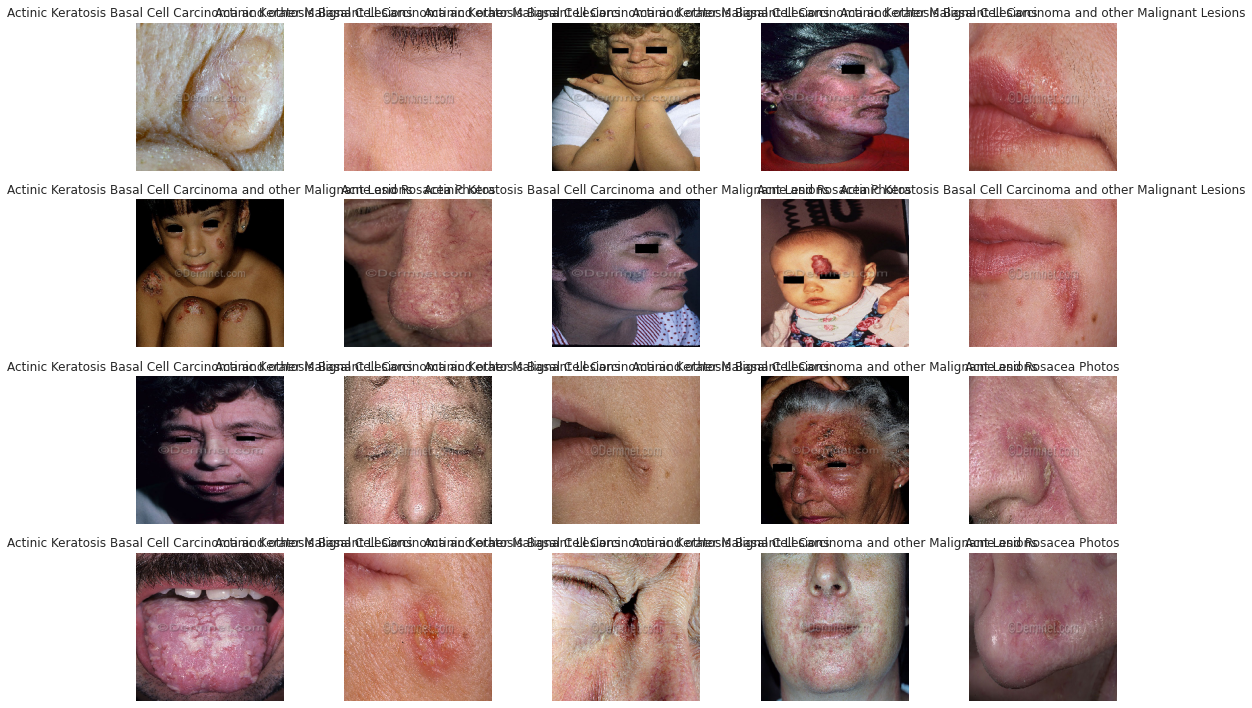

In [8]:
plot_random_images()

# Baseline Model

create a baseline model without Max Pooling Layer.

In [9]:
tf.random.set_seed(42)
model_1 = Sequential([
    Input(shape = (224, 224, 3)), # Input layer    
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), # First Convolutional layer
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), # Second Convolutional layer
    Flatten(),
    Dense(1, activation = 'sigmoid') # Output layer  
])

model_1.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])

history_1 = model_1.fit(train_data,
                        epochs= 5,
                        steps_per_epoch = len(train_data),
                        validation_data = val_data,
                        validation_steps = len(val_data))

Epoch 1/5
88/88 [==============================] - 44s 420ms/step - loss: 1.2993 - accuracy: 0.6807 - val_loss: 0.6103 - val_accuracy: 0.7443
Epoch 2/5
88/88 [==============================] - 25s 286ms/step - loss: 0.5492 - accuracy: 0.7598 - val_loss: 0.5968 - val_accuracy: 0.7500
Epoch 3/5
88/88 [==============================] - 25s 281ms/step - loss: 0.4233 - accuracy: 0.8111 - val_loss: 0.5848 - val_accuracy: 0.7486
Epoch 4/5
88/88 [==============================] - 26s 294ms/step - loss: 0.3236 - accuracy: 0.8778 - val_loss: 0.5061 - val_accuracy: 0.7657
Epoch 5/5
88/88 [==============================] - 25s 285ms/step - loss: 0.2510 - accuracy: 0.9031 - val_loss: 0.5938 - val_accuracy: 0.7771


In [10]:
def plot_loss_curves(history):
    """
    Plots the curves of both loss and accuracy
    """

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(loss))

    fig, ax = plt.subplots(1, 2, figsize = (20, 5))

    # Plotting loss
    ax1 = sns.lineplot(x = epochs, y = loss, label='Training Loss', ax= ax[0])
    ax1 = sns.lineplot(x = epochs, y = val_loss, label='Validation Loss', ax= ax[0])
    ax1.set(title = 'Loss', xlabel = 'Epochs')

    # Plot accuracy
    ax2 = sns.lineplot(x = epochs, y = accuracy, label='Training Accuracy', ax= ax[1])
    ax2 = sns.lineplot(x = epochs, y = val_accuracy, label='Validation Accuracy', ax=ax[1])
    ax2.set(title = 'Accuracy', xlabel = 'Epochs')

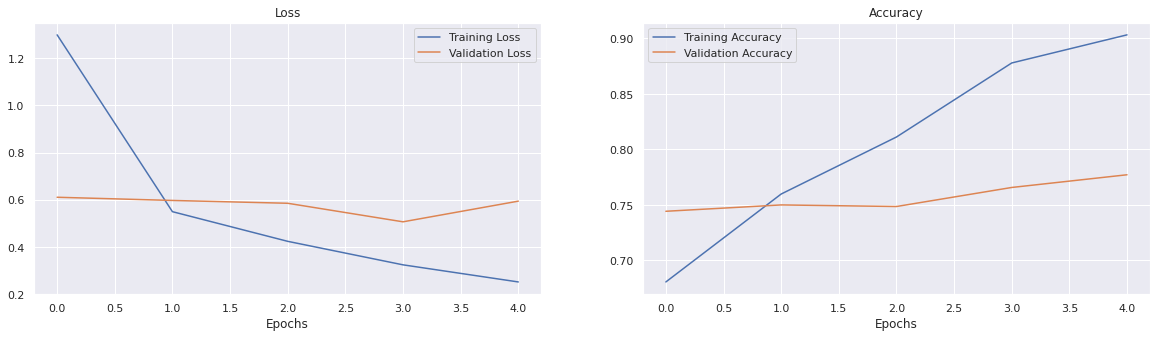

In [11]:
plot_loss_curves(history_1)

Lets add a Max Pooling layer and check whether the accuracy improves or not .

# Max Pooling layer

In [12]:
model_2 = Sequential([
    Input(shape = (224, 224, 3)),   
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'), 
     MaxPool2D(pool_size = 2),# It will reduce the number of features by half
    Conv2D(filters = 32, kernel_size =2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')  
])

model_2.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])

history_2 = model_2.fit(train_data,
                        epochs= 5,
                        steps_per_epoch = len(train_data),
                        validation_data = val_data,
                        validation_steps = len(val_data))

Epoch 1/5
88/88 [==============================] - 26s 294ms/step - loss: 0.6055 - accuracy: 0.7284 - val_loss: 0.5704 - val_accuracy: 0.7443
Epoch 2/5
88/88 [==============================] - 25s 285ms/step - loss: 0.5762 - accuracy: 0.7438 - val_loss: 0.5720 - val_accuracy: 0.7443
Epoch 3/5
88/88 [==============================] - 25s 281ms/step - loss: 0.5504 - accuracy: 0.7477 - val_loss: 0.5585 - val_accuracy: 0.7443
Epoch 4/5
88/88 [==============================] - 25s 285ms/step - loss: 0.5121 - accuracy: 0.7594 - val_loss: 0.5511 - val_accuracy: 0.7500
Epoch 5/5
88/88 [==============================] - 25s 286ms/step - loss: 0.4633 - accuracy: 0.7862 - val_loss: 0.5520 - val_accuracy: 0.7486


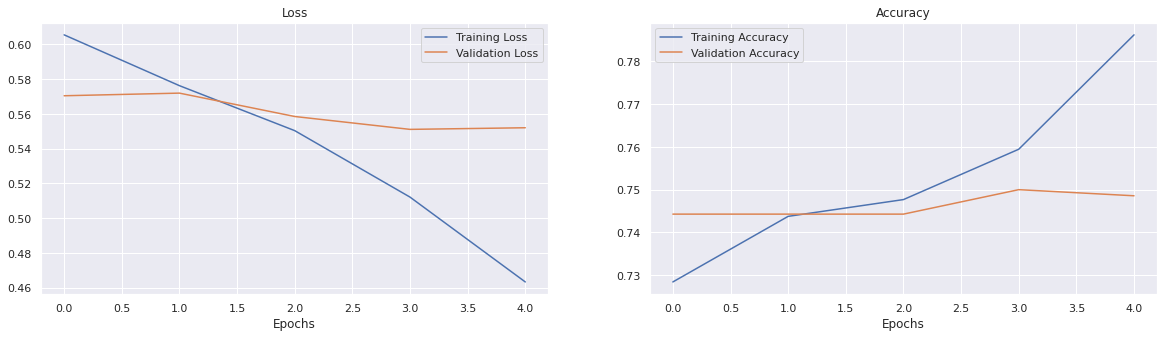

In [13]:
plot_loss_curves(history_2)

We have a maximum validation accuracy of around 75% which is an improvement as compared to our previous model, let us do data augmentation and see whether it improves the accuracy further

# Data Augmentation

In [14]:
data_gen_augmented = ImageDataGenerator(rescale = 1/255., 
                                        validation_split = 0.2,
                                        zoom_range = 0.2,
                                        horizontal_flip= True,
                                        rotation_range = 20,
                                        width_shift_range=0.2,
                                        height_shift_range=0.2)

print('Augmented training Images:')
train_data_augmented = data_gen_augmented.flow_from_directory(data_dir, 
                                                              target_size = (224, 224), 
                                                              batch_size = 32,
                                                              subset = 'training',
                                                              class_mode = 'binary')

print('Unchanged Validation Images:')
val_data = data_gen.flow_from_directory(data_dir, 
                                        target_size = (224, 224), 
                                        batch_size = 32,
                                        subset = 'validation',
                                        class_mode = 'binary')

Augmented training Images:
Found 2806 images belonging to 2 classes.
Unchanged Validation Images:
Found 700 images belonging to 2 classes.


In [15]:
model_3 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])

model_3.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])

history_3 = model_3.fit(train_data_augmented, # changing the training data
                        epochs= 5,
                        steps_per_epoch = len(train_data_augmented),
                        validation_data = val_data,
                        validation_steps = len(val_data))

Epoch 1/5
88/88 [==============================] - 52s 584ms/step - loss: 0.6148 - accuracy: 0.7252 - val_loss: 0.5677 - val_accuracy: 0.7443
Epoch 2/5
88/88 [==============================] - 51s 585ms/step - loss: 0.5777 - accuracy: 0.7441 - val_loss: 0.5880 - val_accuracy: 0.7443
Epoch 3/5
88/88 [==============================] - 51s 582ms/step - loss: 0.5806 - accuracy: 0.7441 - val_loss: 0.5694 - val_accuracy: 0.7443
Epoch 4/5
88/88 [==============================] - 51s 577ms/step - loss: 0.5756 - accuracy: 0.7441 - val_loss: 0.5743 - val_accuracy: 0.7443
Epoch 5/5
88/88 [==============================] - 52s 588ms/step - loss: 0.5785 - accuracy: 0.7438 - val_loss: 0.5697 - val_accuracy: 0.7443


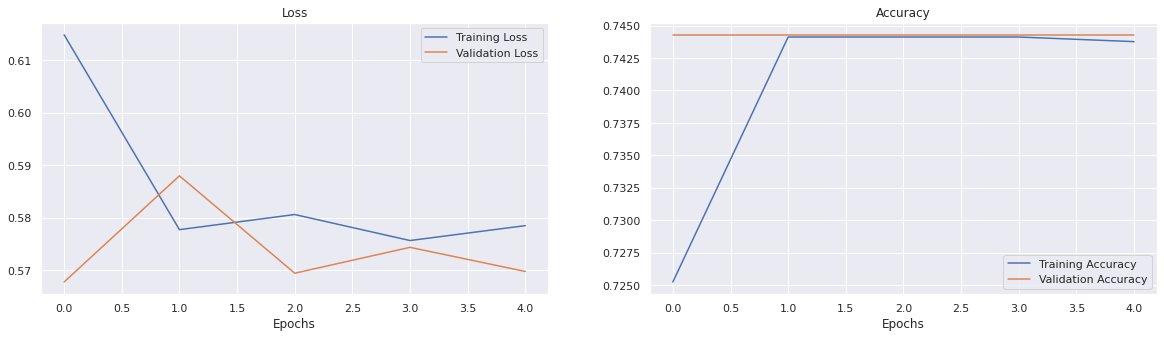

In [16]:
plot_loss_curves(history_3)

We did reach a maximum accuracy of above 75%, lets try to improve the accuracy further.

# Improving Model.

There are lot of things we can change for improving the model such as:
- Increasing the number of epochs 
- Adding more convolutional layers 
- Changing the number of filters 
- Changing the size of our filters 
- Changing the pool size of Max Pooling layer 

In [17]:
model_4 = Sequential([
    Input(shape = (224, 224, 3)),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 32, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Conv2D(filters = 64, kernel_size = 2, padding = 'valid', activation = 'relu'),
    MaxPool2D(pool_size = 2),
    Flatten(),
    Dense(1, activation = 'sigmoid')
])

model_4.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(learning_rate = 0.0001),
                metrics = ['accuracy'])

history_4 = model_4.fit(train_data, # Using non-augmented data
                        epochs= 10,
                        steps_per_epoch = len(train_data),
                        validation_data = val_data,
                        validation_steps = len(val_data))

Epoch 1/10
88/88 [==============================] - 26s 288ms/step - loss: 0.5828 - accuracy: 0.7398 - val_loss: 0.5637 - val_accuracy: 0.7443
Epoch 2/10
88/88 [==============================] - 25s 286ms/step - loss: 0.5723 - accuracy: 0.7441 - val_loss: 0.5637 - val_accuracy: 0.7443
Epoch 3/10
88/88 [==============================] - 25s 290ms/step - loss: 0.5695 - accuracy: 0.7441 - val_loss: 0.5666 - val_accuracy: 0.7443
Epoch 4/10
88/88 [==============================] - 25s 281ms/step - loss: 0.5676 - accuracy: 0.7441 - val_loss: 0.5766 - val_accuracy: 0.7443
Epoch 5/10
88/88 [==============================] - 25s 282ms/step - loss: 0.5723 - accuracy: 0.7441 - val_loss: 0.5633 - val_accuracy: 0.7443
Epoch 6/10
88/88 [==============================] - 25s 286ms/step - loss: 0.5629 - accuracy: 0.7441 - val_loss: 0.5644 - val_accuracy: 0.7443
Epoch 7/10
88/88 [==============================] - 25s 285ms/step - loss: 0.5593 - accuracy: 0.7441 - val_loss: 0.5613 - val_accuracy: 0.7443

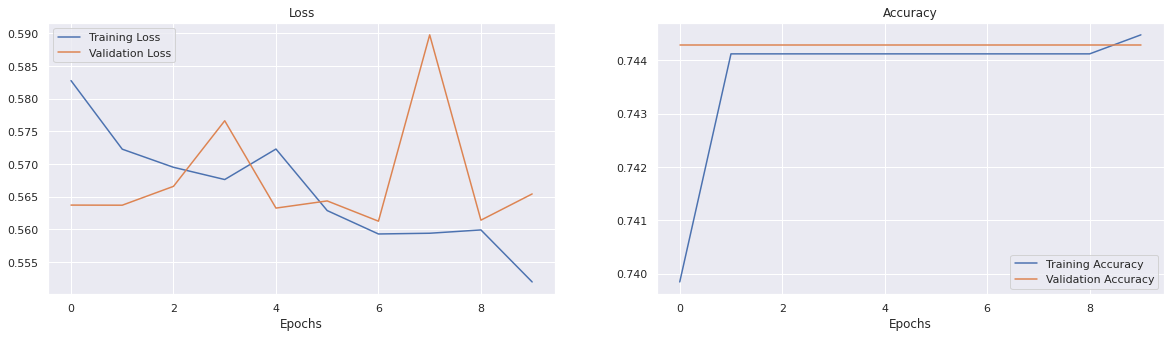

In [18]:
plot_loss_curves(history_4)

#### So we did managed to improve our accuracy to around 80%, which I think is not that bad considering the amount of images we had.

# Transfer Learning

In [19]:
url = 'https://tfhub.dev/google/efficientnet/b7/feature-vector/1'

feature_extractor_layer = hub.KerasLayer(url,
                                         trainable=False,
                                         input_shape=(224, 224, 3))

model_5 = Sequential([
    feature_extractor_layer,
    Dense(1, activation = 'sigmoid')
])

model_5.compile(loss = BinaryCrossentropy(),
                optimizer = Adam(),
                metrics = ['accuracy'])

history_5 = model_5.fit(train_data,
                        epochs= 5,
                        steps_per_epoch = len(train_data),
                        validation_data = val_data,
                        validation_steps = len(val_data))

Epoch 1/5
88/88 [==============================] - 41s 339ms/step - loss: 0.5831 - accuracy: 0.7349 - val_loss: 0.5718 - val_accuracy: 0.7443
Epoch 2/5
88/88 [==============================] - 27s 304ms/step - loss: 0.5576 - accuracy: 0.7384 - val_loss: 0.6022 - val_accuracy: 0.6814
Epoch 3/5
88/88 [==============================] - 28s 320ms/step - loss: 0.5456 - accuracy: 0.7459 - val_loss: 0.5700 - val_accuracy: 0.7429
Epoch 4/5
88/88 [==============================] - 27s 307ms/step - loss: 0.5373 - accuracy: 0.7480 - val_loss: 0.5970 - val_accuracy: 0.6700
Epoch 5/5
88/88 [==============================] - 27s 310ms/step - loss: 0.5333 - accuracy: 0.7530 - val_loss: 0.5965 - val_accuracy: 0.6714


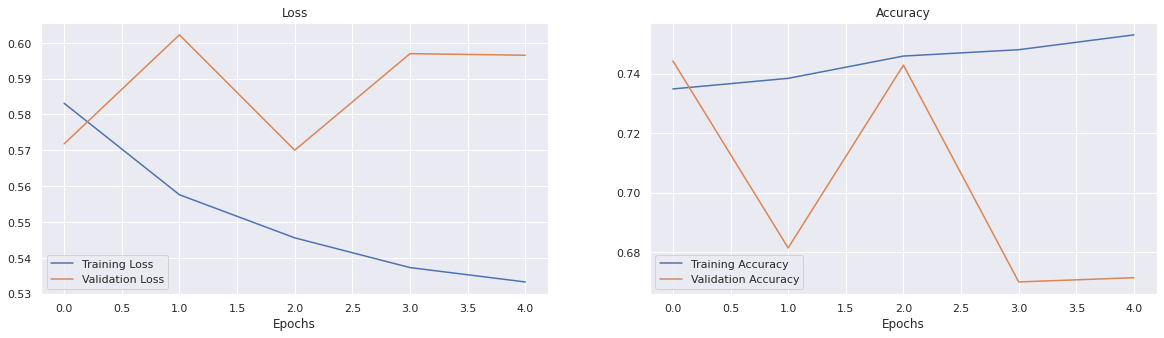

In [20]:
plot_loss_curves(history_5)

So we get a 81% accuracy on our validation set using a EfficientNetB7 Feature vector.